<a href="https://colab.research.google.com/github/20031115dasun/CSACP-Project/blob/Dasun/Homicide.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
homicide_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/database.csv', low_memory=False)
homicide_data.head()

,Record ID,Agency Code,Agency Name,Agency Type,City,State,Year,Month,Incident,Crime Type,...,Victim Ethnicity,Perpetrator Sex,Perpetrator Age,Perpetrator Race,Perpetrator Ethnicity,Relationship,Weapon,Victim Count,Perpetrator Count,Record Source
0,1,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,January,1,Murder or Manslaughter,...,Unknown,Male,15,Native American/Alaska Native,Unknown,Acquaintance,Blunt Object,0,0,FBI
1,2,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,1,Murder or Manslaughter,...,Unknown,Male,42,White,Unknown,Acquaintance,Strangulation,0,0,FBI
2,3,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,2,Murder or Manslaughter,...,Unknown,Unknown,0,Unknown,Unknown,Unknown,Unknown,0,0,FBI
3,4,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,1,Murder or Manslaughter,...,Unknown,Male,42,White,Unknown,Acquaintance,Strangulation,0,0,FBI
4,5,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,2,Murder or Manslaughter,...,Unknown,Unknown,0,Unknown,Unknown,Unknown,Unknown,0,1,FBI


In [58]:
#check whether the dataset has any missing values
print('Homicide Data')
missing_values=homicide_data.isnull().sum()
missing_values

Homicide Data


,0
Record ID,0
Agency Code,0
Agency Name,0
Agency Type,0
City,0
State,0
Year,0
Month,0
Incident,0
Crime Type,0


In [59]:
#Dropping Unrelavant columns for the preditions
homicide_data_new=homicide_data.drop(
    ['Record ID', 'Agency Code', 'Agency Name', 'Agency Type', 'Victim Ethnicity','Perpetrator Ethnicity','City','State', 'Year', 'Month','Incident','Record Source'],
    axis=1,
    errors='ignore'
    )
homicide_data_new.head()

,Crime Type,Crime Solved,Victim Sex,Victim Age,Victim Race,Perpetrator Sex,Perpetrator Age,Perpetrator Race,Relationship,Weapon,Victim Count,Perpetrator Count
0,Murder or Manslaughter,Yes,Male,14,Native American/Alaska Native,Male,15,Native American/Alaska Native,Acquaintance,Blunt Object,0,0
1,Murder or Manslaughter,Yes,Male,43,White,Male,42,White,Acquaintance,Strangulation,0,0
2,Murder or Manslaughter,No,Female,30,Native American/Alaska Native,Unknown,0,Unknown,Unknown,Unknown,0,0
3,Murder or Manslaughter,Yes,Male,43,White,Male,42,White,Acquaintance,Strangulation,0,0
4,Murder or Manslaughter,No,Female,30,Native American/Alaska Native,Unknown,0,Unknown,Unknown,Unknown,0,1


In [60]:
#Check whether does the dataset column crime type contain crimes which does not fall under category Homicide Crimes
invalid_rows = homicide_data_new[
    (homicide_data_new["Crime Type"] != "Murder or Manslaughter") & (homicide_data_new["Crime Type"] != "Manslaughter by Negligence")
]
if  invalid_rows.empty:
    print("No Invalid Rows Found")
else:
    print("Invalid Rows Found")

No Invalid Rows Found


In [61]:
# Convert Perpetrator Age to numeric (handle non-numeric cases)
homicide_data_new['Perpetrator Age'] = pd.to_numeric(homicide_data_new['Perpetrator Age'], errors='coerce')

homicide_data_new = homicide_data_new[homicide_data_new["Perpetrator Age"] > 0]
homicide_data_new.head()

,Crime Type,Crime Solved,Victim Sex,Victim Age,Victim Race,Perpetrator Sex,Perpetrator Age,Perpetrator Race,Relationship,Weapon,Victim Count,Perpetrator Count
0,Murder or Manslaughter,Yes,Male,14,Native American/Alaska Native,Male,15.0,Native American/Alaska Native,Acquaintance,Blunt Object,0,0
1,Murder or Manslaughter,Yes,Male,43,White,Male,42.0,White,Acquaintance,Strangulation,0,0
3,Murder or Manslaughter,Yes,Male,43,White,Male,42.0,White,Acquaintance,Strangulation,0,0
5,Murder or Manslaughter,Yes,Male,30,White,Male,36.0,White,Acquaintance,Rifle,0,0
6,Murder or Manslaughter,Yes,Female,42,Native American/Alaska Native,Male,27.0,Black,Wife,Knife,0,0


In [62]:
# Define the age bins and corresponding numeric labels (ordinal encoding)
bins = [0, 18, 35, 50, 65, 100]
labels = [1, 2, 3, 4, 5]

#categorize the 'Perpetrator Age' into age ranges
homicide_data_new['Age Group'] = pd.cut(homicide_data_new['Perpetrator Age'], bins=bins, labels=labels, right=False)
homicide_data_new = homicide_data_new.drop(columns=['Perpetrator Age'])
homicide_data_new.head()

,Crime Type,Crime Solved,Victim Sex,Victim Age,Victim Race,Perpetrator Sex,Perpetrator Race,Relationship,Weapon,Victim Count,Perpetrator Count,Age Group
0,Murder or Manslaughter,Yes,Male,14,Native American/Alaska Native,Male,Native American/Alaska Native,Acquaintance,Blunt Object,0,0,1
1,Murder or Manslaughter,Yes,Male,43,White,Male,White,Acquaintance,Strangulation,0,0,3
3,Murder or Manslaughter,Yes,Male,43,White,Male,White,Acquaintance,Strangulation,0,0,3
5,Murder or Manslaughter,Yes,Male,30,White,Male,White,Acquaintance,Rifle,0,0,3
6,Murder or Manslaughter,Yes,Female,42,Native American/Alaska Native,Male,Black,Wife,Knife,0,0,2


In [63]:
from sklearn.preprocessing import LabelEncoder

# Encode Perpetrator Sex (Binary)
encoder_sex = LabelEncoder()
homicide_data_new['Perpetrator Sex'] = encoder_sex.fit_transform(homicide_data_new['Perpetrator Sex'])

# Encode Perpetrator Race (Multiclass)
encoder_race = LabelEncoder()
homicide_data_new['Perpetrator Race'] = encoder_race.fit_transform(homicide_data_new['Perpetrator Race'])

homicide_data_new.head()


,Crime Type,Crime Solved,Victim Sex,Victim Age,Victim Race,Perpetrator Sex,Perpetrator Race,Relationship,Weapon,Victim Count,Perpetrator Count,Age Group
0,Murder or Manslaughter,Yes,Male,14,Native American/Alaska Native,1,2,Acquaintance,Blunt Object,0,0,1
1,Murder or Manslaughter,Yes,Male,43,White,1,4,Acquaintance,Strangulation,0,0,3
3,Murder or Manslaughter,Yes,Male,43,White,1,4,Acquaintance,Strangulation,0,0,3
5,Murder or Manslaughter,Yes,Male,30,White,1,4,Acquaintance,Rifle,0,0,3
6,Murder or Manslaughter,Yes,Female,42,Native American/Alaska Native,1,1,Wife,Knife,0,0,2


In [64]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Label Encoding for Binary Columns
binary_cols = ['Crime Solved', 'Victim Sex', 'Perpetrator Sex']
for col in binary_cols:
    homicide_data_new[col] = LabelEncoder().fit_transform(homicide_data_new[col])

# One-Hot Encoding for Multiclass Categorical Columns
multi_cols = ['Crime Type', 'Victim Race', 'Relationship', 'Weapon']
homicide_data_new = pd.get_dummies(homicide_data_new, columns=multi_cols, drop_first=True)

homicide_data_new.head()

,Crime Solved,Victim Sex,Victim Age,Perpetrator Sex,Perpetrator Race,Victim Count,Perpetrator Count,Age Group,Crime Type_Murder or Manslaughter,Victim Race_Black,...,Weapon_Firearm,Weapon_Gun,Weapon_Handgun,Weapon_Knife,Weapon_Poison,Weapon_Rifle,Weapon_Shotgun,Weapon_Strangulation,Weapon_Suffocation,Weapon_Unknown
0,1,1,14,1,2,0,0,1,True,False,...,False,False,False,False,False,False,False,False,False,False
1,1,1,43,1,4,0,0,3,True,False,...,False,False,False,False,False,False,False,True,False,False
3,1,1,43,1,4,0,0,3,True,False,...,False,False,False,False,False,False,False,True,False,False
5,1,1,30,1,4,0,0,3,True,False,...,False,False,False,False,False,True,False,False,False,False
6,1,0,42,1,1,0,0,2,True,False,...,False,False,False,True,False,False,False,False,False,False


In [38]:
homicide_data_new.columns

Index(['Crime Solved', 'Victim Sex', 'Victim Age', 'Perpetrator Sex',
       'Victim Count', 'Perpetrator Count', 'Age Group',
       'Crime Type_Murder or Manslaughter', 'Victim Race_Black',
       'Victim Race_Native American/Alaska Native', 'Victim Race_Unknown',
       'Victim Race_White', 'Relationship_Boyfriend',
       'Relationship_Boyfriend/Girlfriend', 'Relationship_Brother',
       'Relationship_Common-Law Husband', 'Relationship_Common-Law Wife',
       'Relationship_Daughter', 'Relationship_Employee',
       'Relationship_Employer', 'Relationship_Ex-Husband',
       'Relationship_Ex-Wife', 'Relationship_Family', 'Relationship_Father',
       'Relationship_Friend', 'Relationship_Girlfriend',
       'Relationship_Husband', 'Relationship_In-Law', 'Relationship_Mother',
       'Relationship_Neighbor', 'Relationship_Sister', 'Relationship_Son',
       'Relationship_Stepdaughter', 'Relationship_Stepfather',
       'Relationship_Stepmother', 'Relationship_Stepson',
       'Relati

In [66]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import chi2, SelectKBest
import xgboost as xgb
from sklearn.metrics import accuracy_score, mean_squared_error


# Define target variable
y_sex = homicide_data_new["Perpetrator Sex"]

# Drop target variable from features
X_sex = homicide_data_new.drop(["Perpetrator Sex", "Perpetrator Race", "Age Group"], axis=1)

# Scale features
scaler = MinMaxScaler()
X_sex_scaled = scaler.fit_transform(X_sex)

# Perform Chi-Square test for feature selection
chi2_sex, p_values_sex = chi2(X_sex_scaled, y_sex)

# Select features with p-value < 0.05
selected_features_sex = X_sex.columns[p_values_sex < 0.05].tolist()
# Print selected features for the Sex model
print(f"Selected Features for Perpetrator Sex Model: {selected_features_sex}")

# Train-Test Split (80-20)
X_train_sex, X_test_sex, y_train_sex, y_test_sex = train_test_split(homicide_data_new[selected_features_sex], y_sex, test_size=0.2, random_state=42)

# Train XGBoost Model for Sex Prediction
model_sex = xgb.XGBClassifier(objective="binary:logistic")
model_sex.fit(X_train_sex, y_train_sex)

# Make Predictions
y_pred_sex = model_sex.predict(X_test_sex)

# Model Evaluation
accuracy_sex = accuracy_score(y_test_sex, y_pred_sex)

# Print Results
print(f"Perpetrator Sex Model Accuracy: {accuracy_sex:.4f}")


Selected Features for Perpetrator Sex Model: ['Crime Solved', 'Victim Sex', 'Victim Count', 'Perpetrator Count', 'Victim Race_Black', 'Victim Race_Unknown', 'Victim Race_White', 'Relationship_Boyfriend', 'Relationship_Boyfriend/Girlfriend', 'Relationship_Brother', 'Relationship_Common-Law Husband', 'Relationship_Common-Law Wife', 'Relationship_Daughter', 'Relationship_Employer', 'Relationship_Ex-Husband', 'Relationship_Ex-Wife', 'Relationship_Family', 'Relationship_Friend', 'Relationship_Girlfriend', 'Relationship_Husband', 'Relationship_In-Law', 'Relationship_Mother', 'Relationship_Neighbor', 'Relationship_Sister', 'Relationship_Son', 'Relationship_Stepdaughter', 'Relationship_Stepfather', 'Relationship_Stepson', 'Relationship_Stranger', 'Relationship_Unknown', 'Relationship_Wife', 'Weapon_Drowning', 'Weapon_Drugs', 'Weapon_Fall', 'Weapon_Fire', 'Weapon_Firearm', 'Weapon_Gun', 'Weapon_Handgun', 'Weapon_Knife', 'Weapon_Poison', 'Weapon_Rifle', 'Weapon_Shotgun', 'Weapon_Strangulation', 

In [68]:
# Define target variable
y_race = homicide_data_new["Perpetrator Race"]

# Drop target variable from features
X_race = homicide_data_new.drop(["Perpetrator Sex", "Perpetrator Race", "Age Group"], axis=1)

# Scale features
scaler = MinMaxScaler()
X_race_scaled = scaler.fit_transform(X_race)

# Perform Chi-Square test for feature selection
chi2_race, p_values_race = chi2(X_race_scaled, y_race)

# Select features with p-value < 0.05
selected_features_race = X_race.columns[p_values_race < 0.05].tolist()
# Print selected features for the Sex model
print(f"Selected Features for Perpetrator race Model: {selected_features_race}")

# Train-Test Split (80-20)
X_train_race, X_test_race, y_train_race, y_test_race = train_test_split(homicide_data_new[selected_features_race], y_race, test_size=0.2, random_state=42)

# Train XGBoost Model for Race Prediction
model_race = xgb.XGBClassifier(objective="multi:softmax", num_class=len(y_race.unique()))
model_race.fit(X_train_race, y_train_race)

# Make Predictions
y_pred_race = model_race.predict(X_test_race)

# Model Evaluation
accuracy_race = accuracy_score(y_test_race, y_pred_race)

# Print Results
print(f"Perpetrator Race Model Accuracy: {accuracy_race:.4f}")


Selected Features for Perpetrator race Model: ['Crime Solved', 'Victim Sex', 'Victim Age', 'Victim Count', 'Perpetrator Count', 'Crime Type_Murder or Manslaughter', 'Victim Race_Black', 'Victim Race_Native American/Alaska Native', 'Victim Race_Unknown', 'Victim Race_White', 'Relationship_Boyfriend', 'Relationship_Boyfriend/Girlfriend', 'Relationship_Brother', 'Relationship_Common-Law Husband', 'Relationship_Common-Law Wife', 'Relationship_Daughter', 'Relationship_Employee', 'Relationship_Employer', 'Relationship_Ex-Husband', 'Relationship_Ex-Wife', 'Relationship_Family', 'Relationship_Father', 'Relationship_Friend', 'Relationship_Girlfriend', 'Relationship_Husband', 'Relationship_In-Law', 'Relationship_Mother', 'Relationship_Neighbor', 'Relationship_Sister', 'Relationship_Son', 'Relationship_Stepdaughter', 'Relationship_Stepfather', 'Relationship_Stepmother', 'Relationship_Stepson', 'Relationship_Stranger', 'Relationship_Unknown', 'Relationship_Wife', 'Weapon_Drowning', 'Weapon_Drugs',

In [69]:
# Define target variable
y_age = homicide_data_new["Age Group"]

# Drop target variable from features
X_age = homicide_data_new.drop(["Perpetrator Sex", "Perpetrator Race", "Age Group"], axis=1)

# Perform Chi-Square test for feature selection (before scaling)
chi2_age, p_values_age = chi2(X_age, y_age)

# Select features with p-value < 0.05
selected_features_age = X_age.columns[p_values_age < 0.05].tolist()

# Print selected features for the Age model
print(f"Selected Features for Perpetrator Age Model: {selected_features_age}")

# Filter X_age to include only selected features
X_age_selected = X_age[selected_features_age]

# Train-Test Split (80-20)
X_train_age, X_test_age, y_train_age, y_test_age = train_test_split(X_age_selected, y_age, test_size=0.2, random_state=42)

# Scale features
scaler = MinMaxScaler()
X_train_age_scaled = scaler.fit_transform(X_train_age)
X_test_age_scaled = scaler.transform(X_test_age)

# Train XGBoost Model for Age Prediction
model_age = xgb.XGBRegressor(objective="reg:squarederror")
model_age.fit(X_train_age_scaled, y_train_age)

# Make Predictions
y_pred_age = model_age.predict(X_test_age_scaled)

# Model Evaluation
mse_age = mean_squared_error(y_test_age, y_pred_age)

# Print Results
print(f"Perpetrator Age Model MSE: {mse_age:.4f}")


Selected Features for Perpetrator Age Model: ['Victim Sex', 'Victim Age', 'Victim Count', 'Perpetrator Count', 'Crime Type_Murder or Manslaughter', 'Victim Race_Black', 'Victim Race_Native American/Alaska Native', 'Victim Race_Unknown', 'Victim Race_White', 'Relationship_Boyfriend', 'Relationship_Boyfriend/Girlfriend', 'Relationship_Brother', 'Relationship_Common-Law Husband', 'Relationship_Common-Law Wife', 'Relationship_Daughter', 'Relationship_Employee', 'Relationship_Employer', 'Relationship_Ex-Husband', 'Relationship_Ex-Wife', 'Relationship_Family', 'Relationship_Father', 'Relationship_Friend', 'Relationship_Girlfriend', 'Relationship_Husband', 'Relationship_In-Law', 'Relationship_Mother', 'Relationship_Neighbor', 'Relationship_Sister', 'Relationship_Son', 'Relationship_Stepdaughter', 'Relationship_Stepfather', 'Relationship_Stepmother', 'Relationship_Stepson', 'Relationship_Stranger', 'Relationship_Unknown', 'Relationship_Wife', 'Weapon_Drowning', 'Weapon_Drugs', 'Weapon_Explosiv

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the features and their corresponding target variable
features_sex = homicide_data_new[selected_features_sex]
features_race = homicide_data_new[selected_features_race]
features_age = homicide_data_new[selected_features_age]

# Adding the target variables to the features for correlation matrix
features_sex['Perpetrator Sex'] = homicide_data_new['Perpetrator Sex']
features_race['Perpetrator Race'] = homicide_data_new['Perpetrator Race']
features_age['Age Group'] = homicide_data_new['Age Group']

# Calculate the correlation matrix
corr_matrix_sex = features_sex.corr()
corr_matrix_race = features_race.corr()
corr_matrix_age = features_age.corr()

<ipython-input-70-d19284278cf2>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features_sex['Perpetrator Sex'] = homicide_data_new['Perpetrator Sex']
<ipython-input-70-d19284278cf2>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features_race['Perpetrator Race'] = homicide_data_new['Perpetrator Race']
<ipython-input-70-d19284278cf2>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in

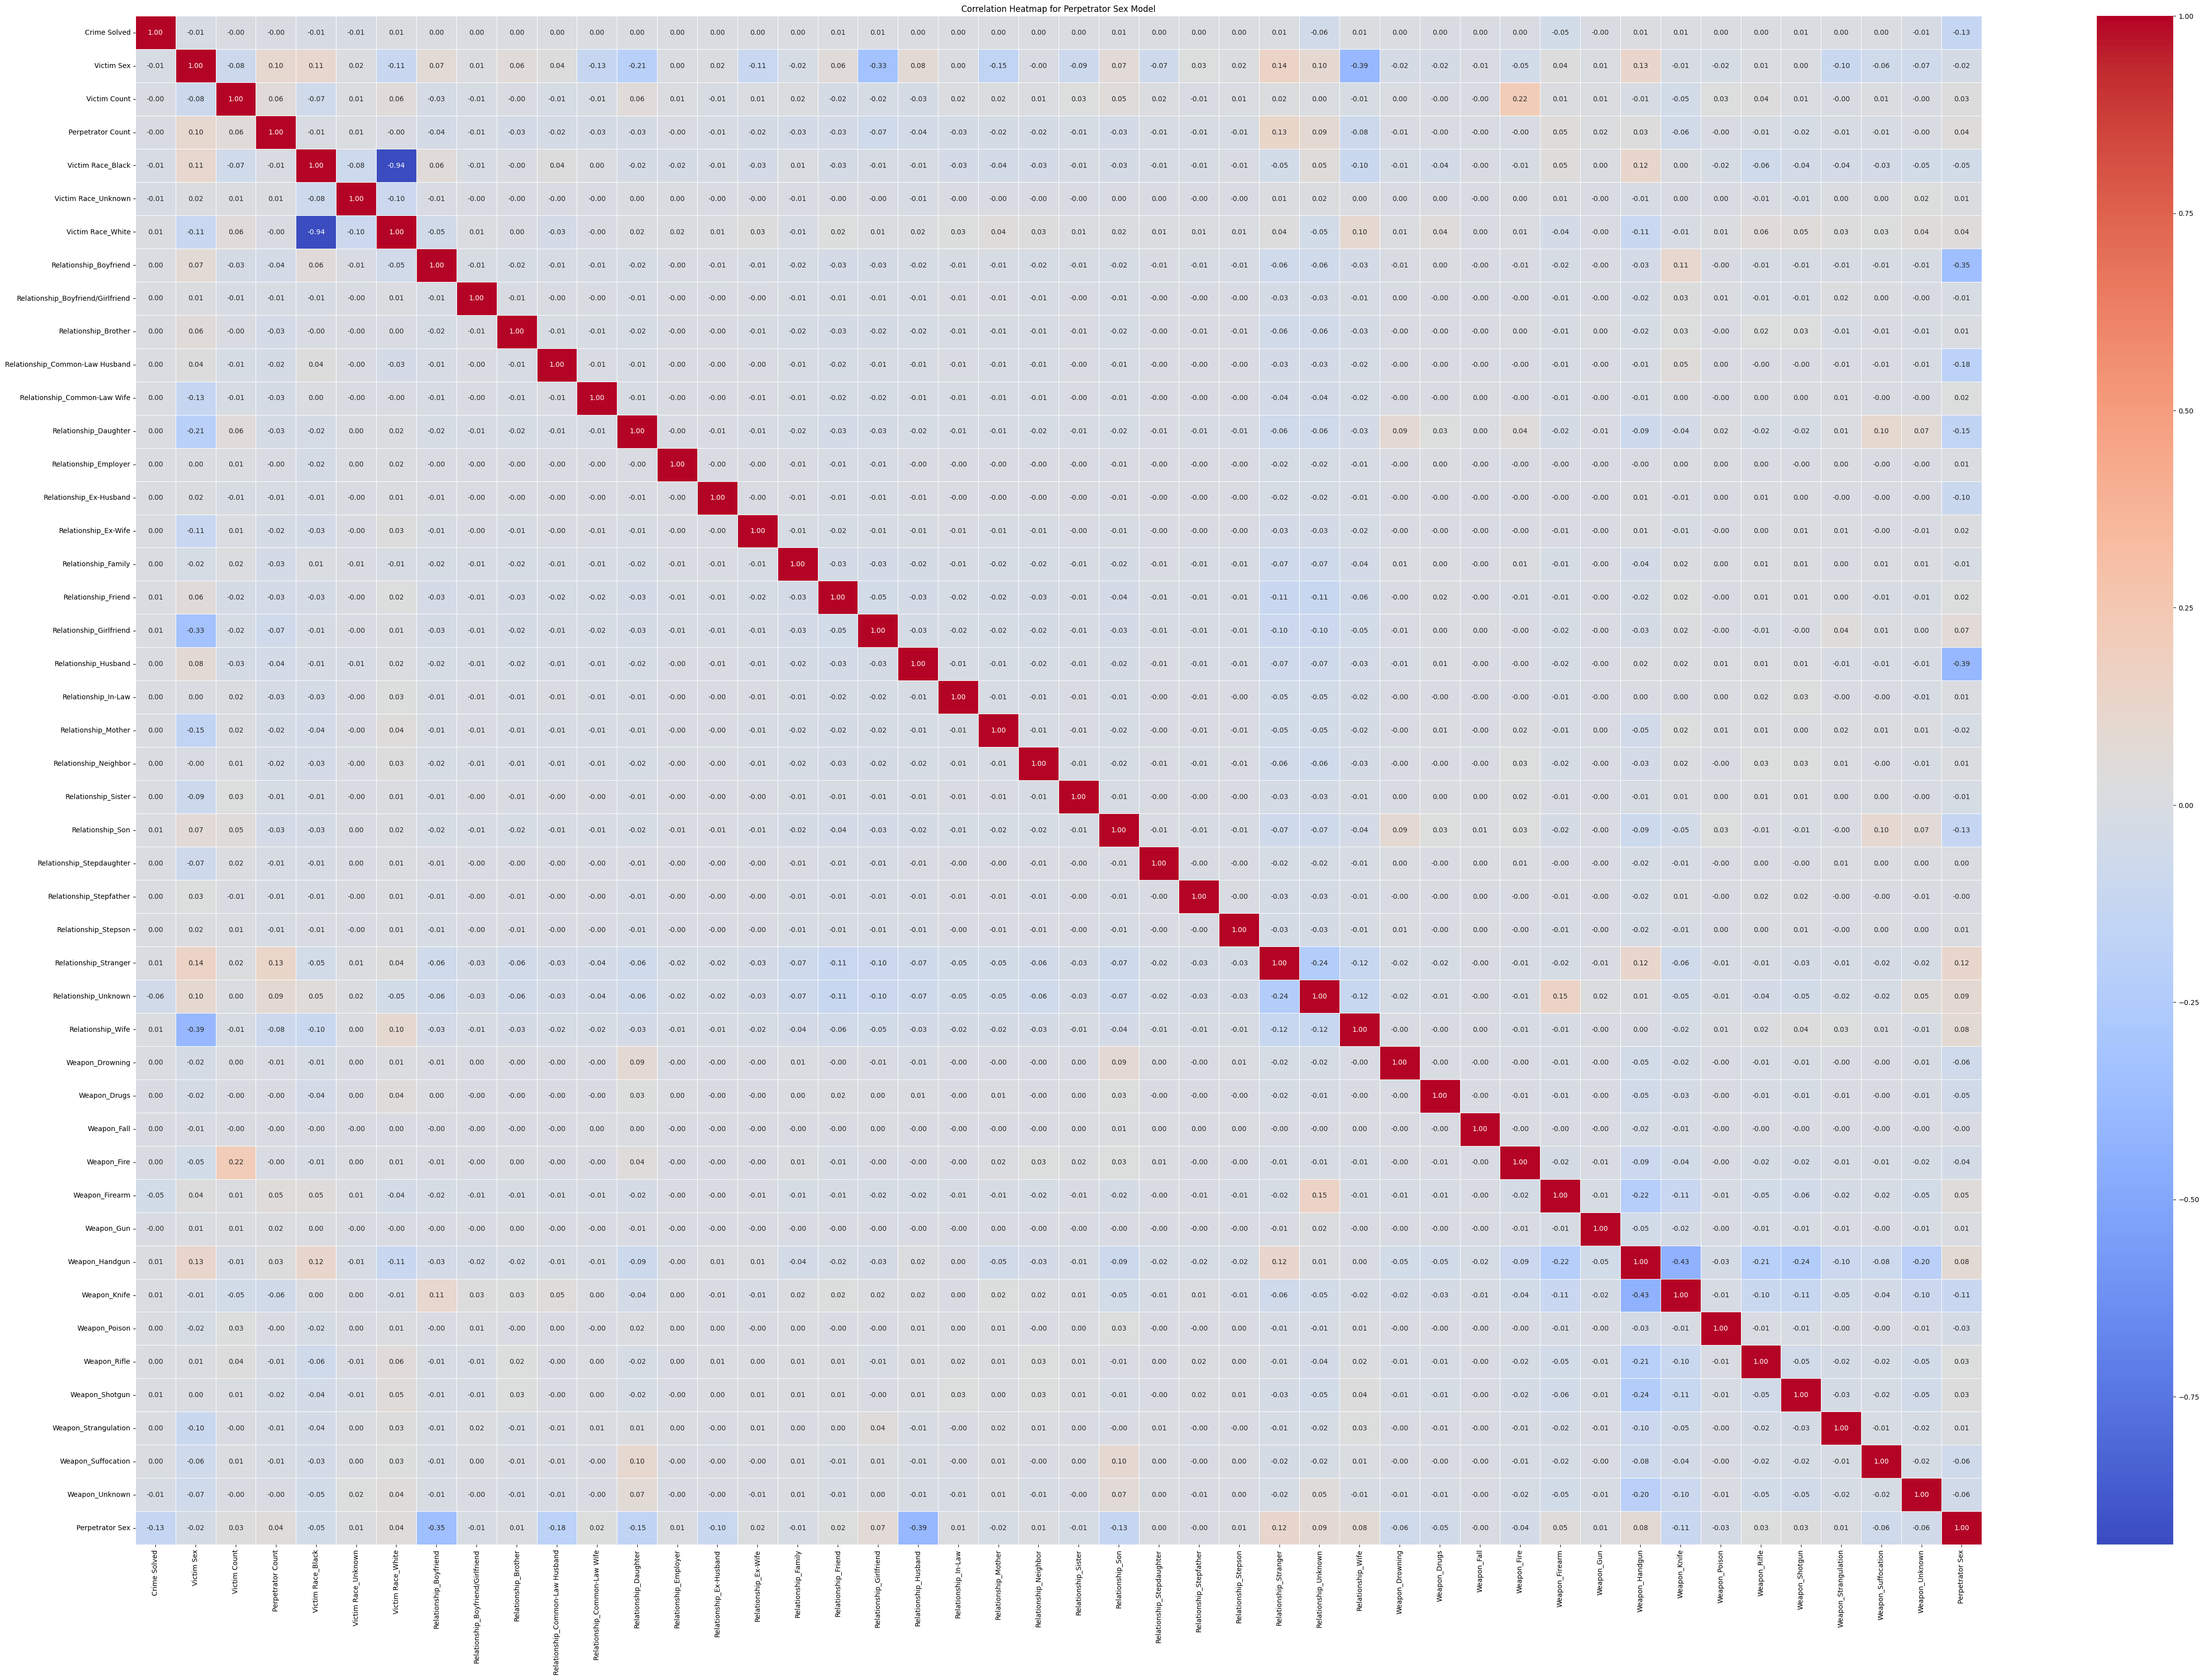

In [76]:
# Plot the heatmap for Perpetrator Sex model
plt.figure(figsize=(60, 40))
sns.heatmap(corr_matrix_sex, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap for Perpetrator Sex Model')
plt.show()

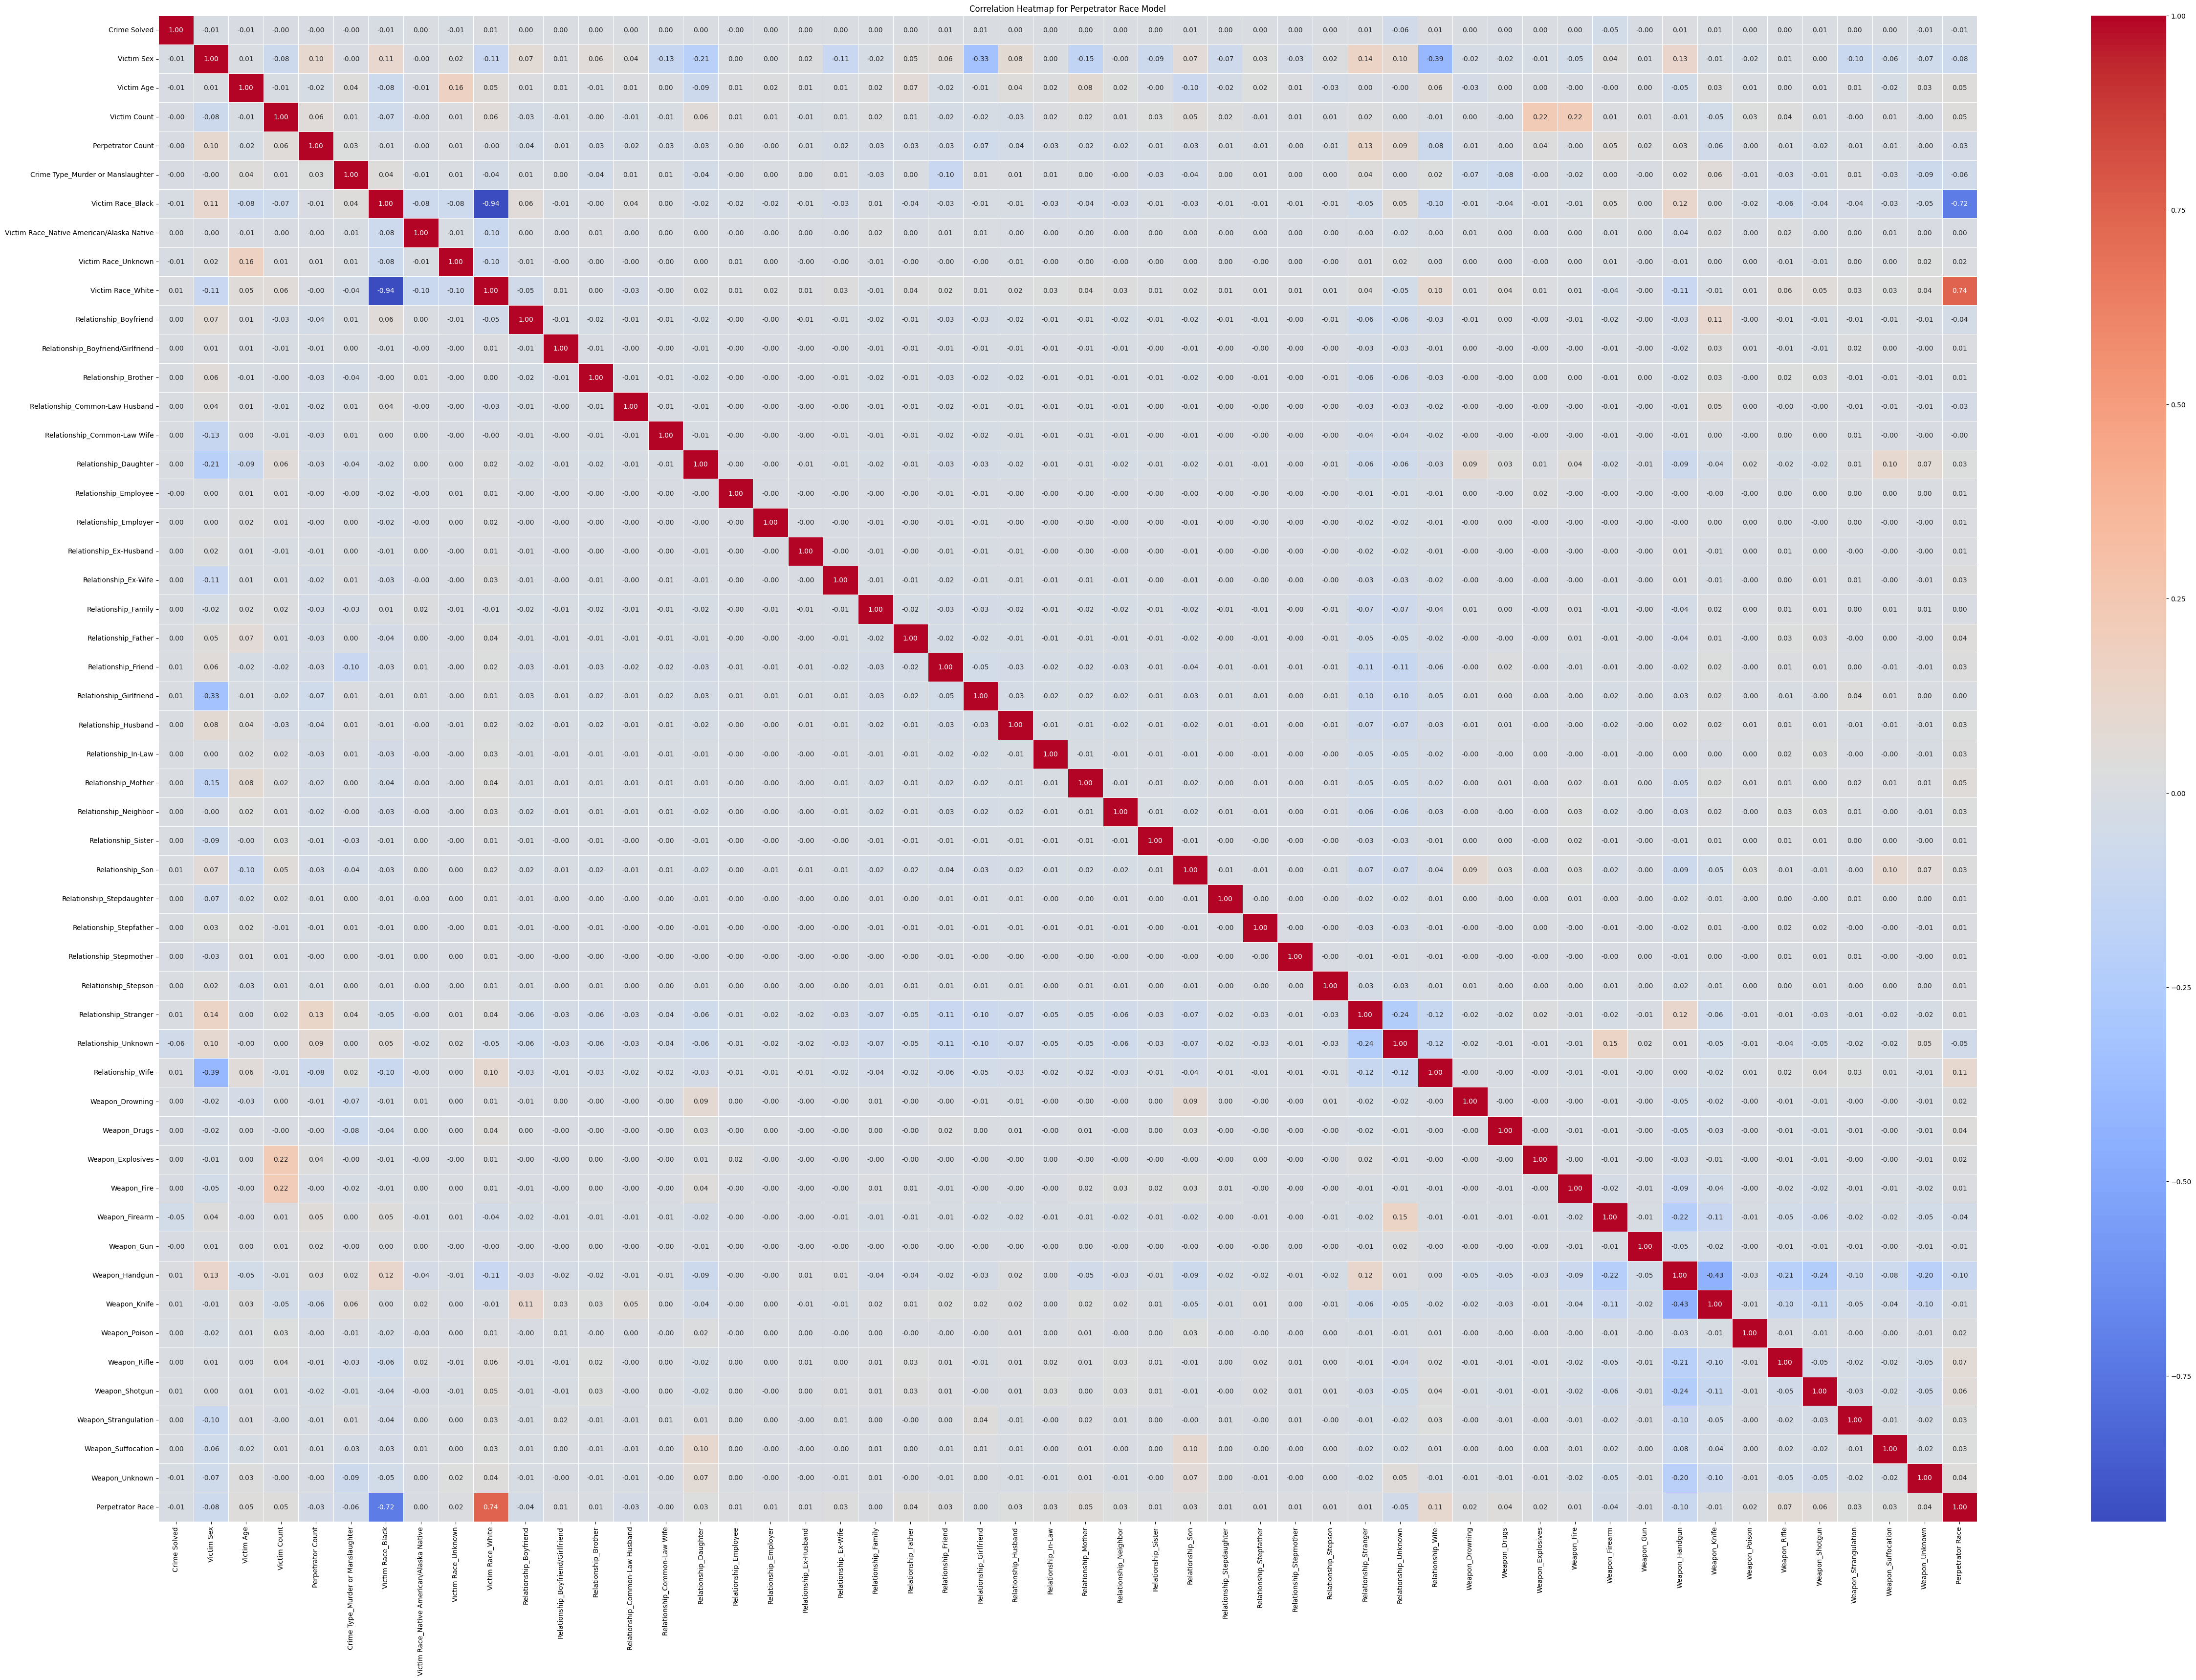

In [77]:
# Plot the heatmap for Perpetrator Race model
plt.figure(figsize=(60, 40))
sns.heatmap(corr_matrix_race, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap for Perpetrator Race Model')
plt.show()

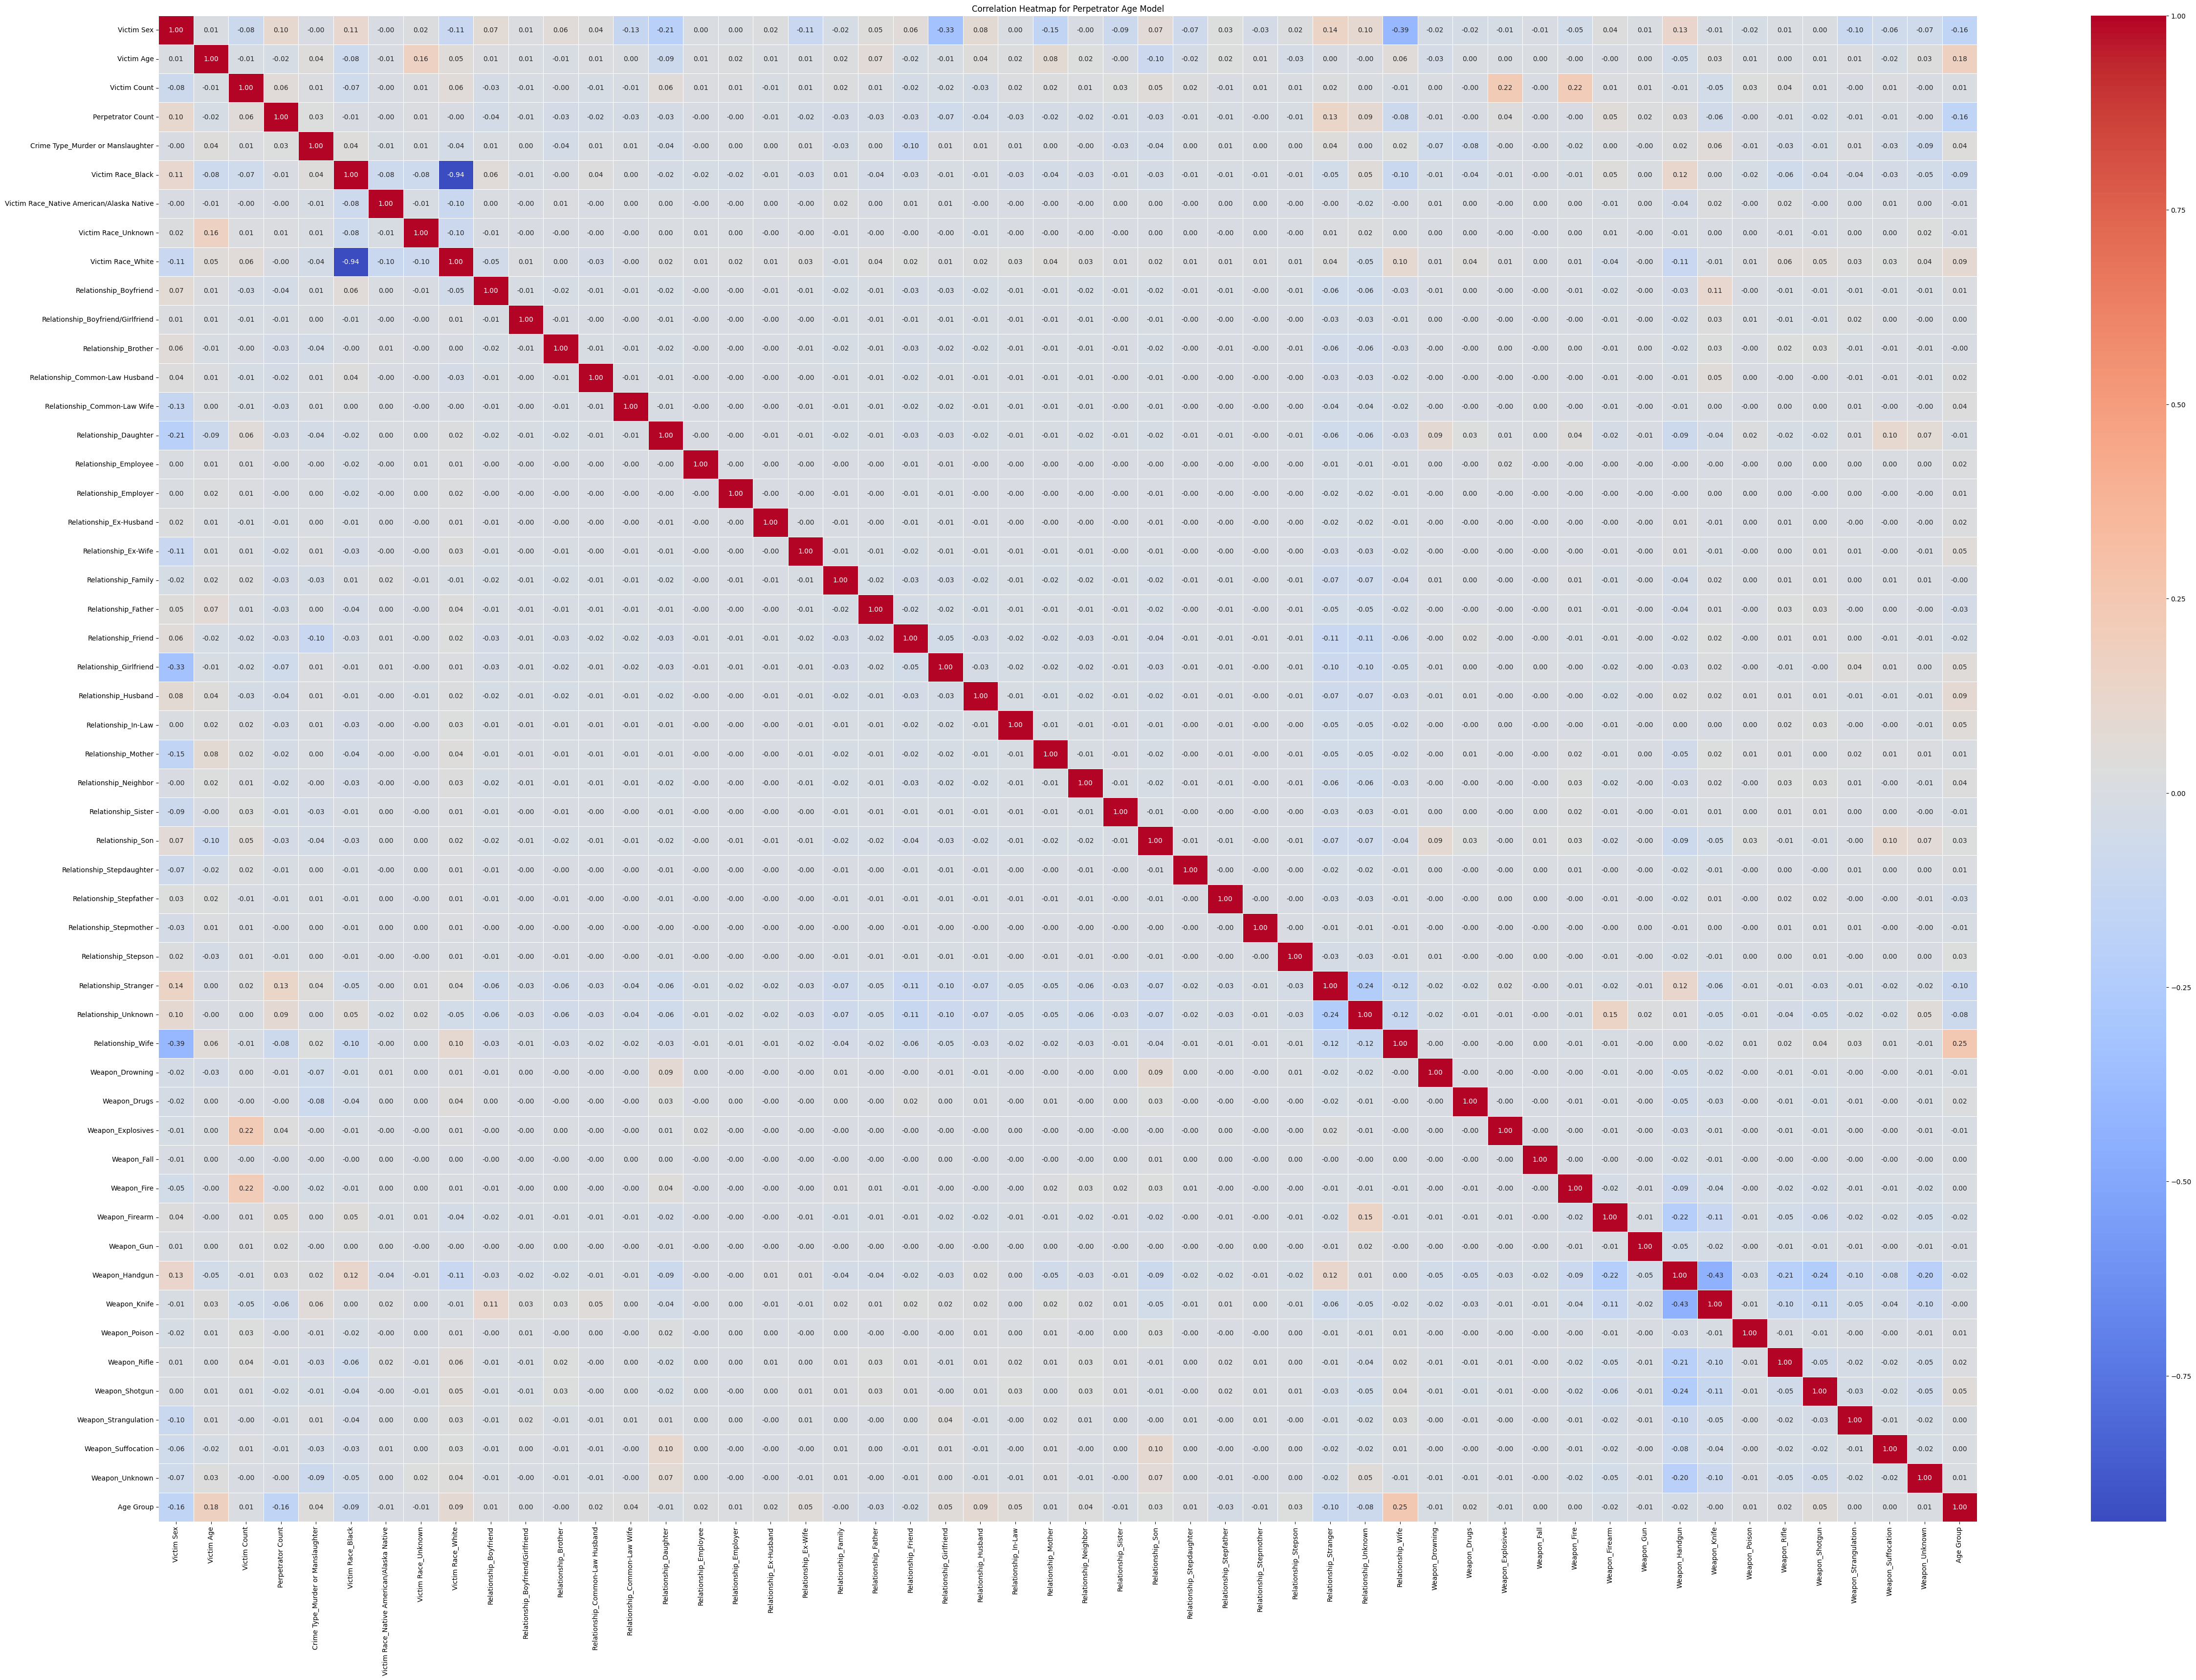

In [78]:
# Plot the heatmap for Perpetrator Age model
plt.figure(figsize=(60, 40))
sns.heatmap(corr_matrix_age, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap for Perpetrator Age Model')
plt.show()